In [4]:
import mlflow 

mlflow.set_tracking_uri("http://ec2-100-25-213-249.compute-1.amazonaws.com:5000/")

with mlflow.start_run():
    mlflow.log_param('param1', 15)
    mlflow.log_metric('metric1', 0.89)

🏃 View run skillful-gnu-266 at: http://ec2-100-25-213-249.compute-1.amazonaws.com:5000/#/experiments/0/runs/387d36ae18fb47888aee9788af09f18c
🧪 View experiment at: http://ec2-100-25-213-249.compute-1.amazonaws.com:5000/#/experiments/0


In [5]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
print(df.shape)

df.head()

(37249, 2)


,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [7]:
df.dropna(inplace = True)
df.drop_duplicates(inplace = True)
df = df[~(df.clean_comment.str.strip() == '')]

In [8]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [9]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/carlosgordilloolivera/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/carlosgordilloolivera/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
def preprocess_comment(comment):
    comment = comment.lower().strip()
    comment = re.sub(r'\n',' ', comment)
    comment = re.sub(r'[^A-Za-z0-9\s!?.,]','',comment)
    stop_words = set(stopwords.words('english')) - {'not','but','however','no','yet'}
    comment = ' '.join([word for word in comment.split() if word not in stop_words])
    lemmatizer = WordNetLemmatizer()
    comment = ' '.join([lemmatizer.lemmatize(word) for word in comment.split()])
    return comment

In [11]:
df.clean_comment = df.clean_comment.apply(preprocess_comment)

In [12]:
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [13]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
vectorizer = CountVectorizer(max_features = 10000)

In [17]:
X = vectorizer.fit_transform(df.clean_comment).toarray()
y = df.category

In [ ]:
mlflow.set_registry_uri("http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/")

In [43]:
mlflow.set_tracking_uri("http://ec2-98-89-26-222.compute-1.amazonaws.com:5000")

In [45]:
mlflow.set_experiment('RF Baseline')

<Experiment: artifact_location='s3://mlflow-bucket-carlos/1', creation_time=1772586987713, experiment_id='1', last_update_time=1772586987713, lifecycle_stage='active', name='RF Baseline', tags={}>

In [46]:
from dotenv import load_dotenv
import os

load_dotenv()

import boto3
import os

session = boto3.Session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")
)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

🏃 View run RandomForest_Baseline_TrainTestSplit at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/1/runs/1160a760585145c5a2f4c5a7b181283e
🧪 View experiment at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/1
Accuracy: 0.6483217828509308


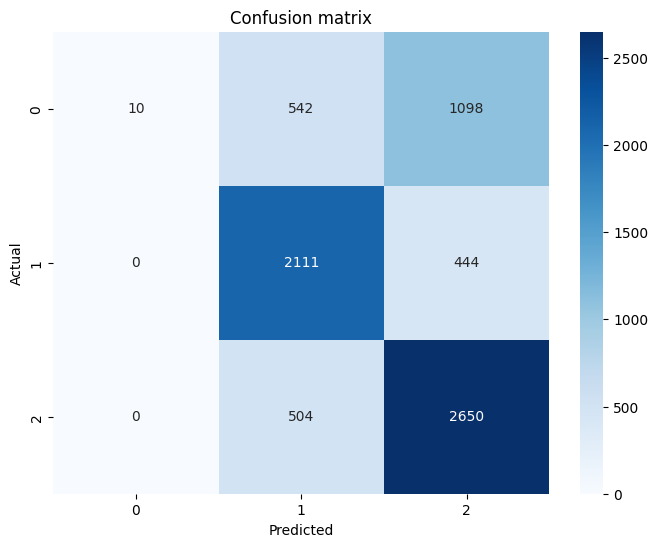

In [48]:
with mlflow.start_run() as run:
    mlflow.set_tag('mlflow.runName', 'RandomForest_Baseline_TrainTestSplit')
    mlflow.set_tag('experiment_type','baseline')
    mlflow.set_tag('model_type','RandomForestClassifier')
    
    mlflow.set_tag('description','Baseline RandomForest model for sentiment analysis using Bag of Words (BoW)')
    
    mlflow.log_param('vectorizer_type','CountVectorizer')
    mlflow.log_param('vectorizer_max_features',vectorizer.max_features)
    
    n_estimators = 200
    max_depth = 15
    
    mlflow.log_param('n_estimators',n_estimators)
    mlflow.log_param('max_depth', max_depth)
    
    model = RandomForestClassifier(n_estimators = n_estimators, max_depth = max_depth, random_state = 42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric('accuracy',accuracy)
    
    classification_rep = classification_report(y_test, y_pred, output_dict = True)
    
    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):
            for metric, value in metrics.items():
                mlflow.log_metric(f'{label}_{metric}', value)
                
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize = (8,6))
    sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion matrix')
    
    plt.savefig('confusion_matrix.png')
    mlflow.log_artifact("confusion_matrix.png")
    
    df.to_csv('dataset.csv', index = False)
    mlflow.log_artifact('dataset.csv')
    
    mlflow.sklearn.log_model(
        model,
        "random_forest_model",
        input_example=X_train[:5]
    )
    
print(f'Accuracy: {accuracy}')

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          -1       1.00      0.01      0.01      1650
           0       0.67      0.83      0.74      2555
           1       0.63      0.84      0.72      3154

    accuracy                           0.65      7359
   macro avg       0.77      0.56      0.49      7359
weighted avg       0.73      0.65      0.57      7359



In [ ]:
df.to_csv('reddit_preprocessing.csv', index = False)